<a href="https://colab.research.google.com/github/aditya-singh004/Student-Productivity-Analyzer/blob/main/productivity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import os
import kagglehub
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split



In [ ]:
path = kagglehub.dataset_download("sehaj1104/student-productivity-and-digital-distraction-dataset")

files = []
for root, dirs, filenames in os.walk(path):
    for f in filenames:
        if f.endswith(".csv"):
            files.append(os.path.join(root, f))

df = pd.read_csv(files[0])
df.head()


Using Colab cache for faster access to the 'student-productivity-and-digital-distraction-dataset' dataset.


,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90


In [ ]:
df = df.drop_duplicates()
df = df.replace(["NA", "N/A", "na", "n/a", "?", ""], np.nan)


In [ ]:
for col in df.columns:
    if df[col].dtype == "object":
        try:
            df[col] = pd.to_numeric(df[col])
        except:
            pass


In [ ]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns


In [ ]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


In [ ]:
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()


In [ ]:
high_card_cols = [col for col in cat_cols if df[col].nunique() > 10]
low_card_cols = [col for col in cat_cols if df[col].nunique() <= 10]


In [ ]:
df_encoded = df.copy()

for col in high_card_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])


In [ ]:
if len(low_card_cols) > 0:
    ohe = OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore")
    ohe_data = ohe.fit_transform(df_encoded[low_card_cols])
    ohe_df = pd.DataFrame(
        ohe_data,
        columns=ohe.get_feature_names_out(low_card_cols),
        index=df_encoded.index
    )
    df_encoded = df_encoded.drop(columns=low_card_cols)
    df_encoded = pd.concat([df_encoded, ohe_df], axis=1)



In [ ]:
num_cols_final = df_encoded.select_dtypes(include=["int64", "float64"]).columns
scaler = StandardScaler()
df_encoded[num_cols_final] = scaler.fit_transform(df_encoded[num_cols_final])


In [ ]:
target_column = None
for col in df_encoded.columns:
    if "productivity" in col.lower():
        target_column = col
        break

if target_column is None:
    target_column = df_encoded.columns[-1]


In [ ]:
X = df_encoded.drop(columns=[target_column])
y = df_encoded[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
processed_path = "processed_data.csv"
df_encoded.to_csv(processed_path, index=False)

print("Processed dataset saved at:", os.path.abspath(processed_path))
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Processed dataset saved at: /content/processed_data.csv
Train shape: (16000, 18)
Test shape: (4000, 18)


In [ ]:
target_column = "productivity_score"

X = df_encoded.drop(columns=[target_column])
y = df_encoded[target_column]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [ ]:
import numpy as np

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results[name] = {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

results



{'Linear Regression': {'RMSE': np.float64(0.00017860151876791997),
  'MAE': 0.0001544033512623768,
  'R2': 0.9999999679557454},
 'Ridge': {'RMSE': np.float64(0.0001903777721456837),
  'MAE': 0.0001618997219649875,
  'R2': 0.9999999635906975},
 'Lasso': {'RMSE': np.float64(0.9977784279567293),
  'MAE': 0.8124242155287653,
  'R2': -0.00011075684671291164},
 'Random Forest': {'RMSE': np.float64(0.15772688404660454),
  'MAE': 0.12390978119429605,
  'R2': 0.9750085574276408},
 'Gradient Boosting': {'RMSE': np.float64(0.08743267095169378),
  'MAE': 0.0691542173206619,
  'R2': 0.9923205985864483}}

In [ ]:
corr = df_encoded.corr()["productivity_score"].sort_values(ascending=False)
corr.head(10)


,productivity_score
productivity_score,1.000000
study_hours_per_day,0.732777
focus_score,0.411366
sleep_hours,0.340902
attendance_percentage,0.176107
student_id,0.012579
coffee_intake_mg,0.010190
gender_male,0.005000
exercise_minutes,0.002892
final_grade,0.001954


In [ ]:
print("productivity_score" in X_train.columns)


False


In [ ]:
target_column = "productivity_score"

X = df_encoded.drop(columns=[target_column])
y = df_encoded[target_column]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}

results


{'Linear Regression': {'RMSE': np.float64(0.00017860151876791067),
  'MAE': 0.00015440335126235777,
  'R2': 0.9999999679557454},
 'Random Forest': {'RMSE': np.float64(0.15771548973206176),
  'MAE': 0.12392639008508678,
  'R2': 0.9750121681002742},
 'Gradient Boosting': {'RMSE': np.float64(0.08743914914126094),
  'MAE': 0.06916129593023358,
  'R2': 0.992319460557366}}

In [ ]:
best_model = GradientBoostingRegressor(random_state=42)
best_model.fit(X_train, y_train)

import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance.head(10)


,Feature,Importance
2,study_hours_per_day,0.543309
14,focus_score,0.166589
3,sleep_hours,0.114185
4,phone_usage_hours,0.110676
13,stress_level,0.035025
12,attendance_percentage,0.030216
1,age,0.000000
0,student_id,0.000000
6,youtube_hours,0.000000
5,social_media_hours,0.000000


In [ ]:
drop_cols = ["student_id", "age", "youtube_hours", "social_media_hours"]
X = X.drop(columns=[col for col in drop_cols if col in X.columns])


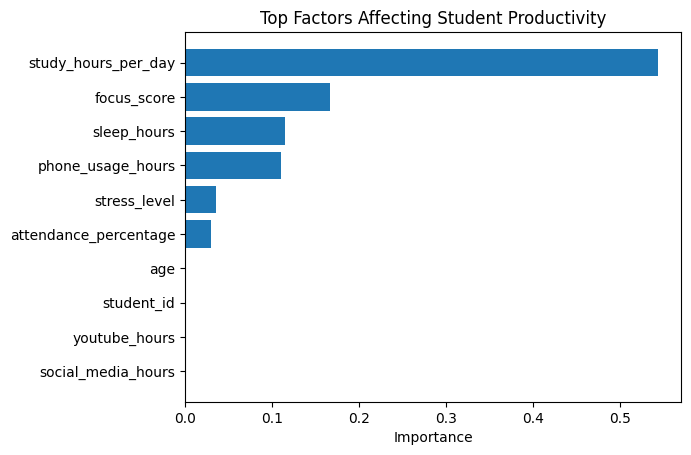

In [ ]:
import matplotlib.pyplot as plt

importance_top = importance.head(10)

plt.figure()
plt.barh(importance_top["Feature"], importance_top["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top Factors Affecting Student Productivity")
plt.show()


In [ ]:
import pandas as pd

results_df = pd.DataFrame(results).T
results_df


,RMSE,MAE,R2
Linear Regression,0.000179,0.000154,1.000000
Random Forest,0.157715,0.123926,0.975012
Gradient Boosting,0.087439,0.069161,0.992319


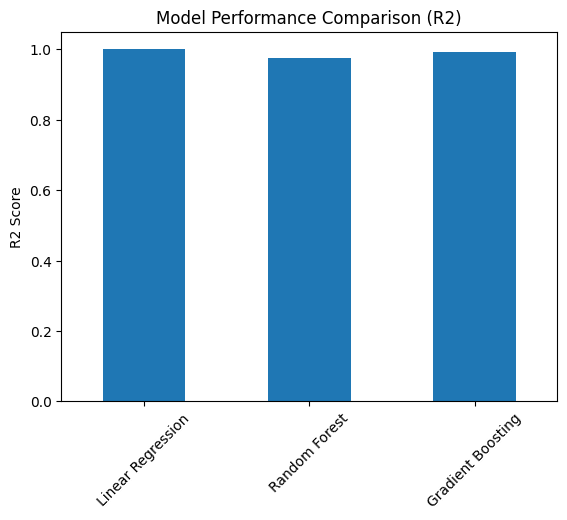

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
results_df["R2"].plot(kind="bar")
plt.ylabel("R2 Score")
plt.title("Model Performance Comparison (R2)")
plt.xticks(rotation=45)
plt.show()


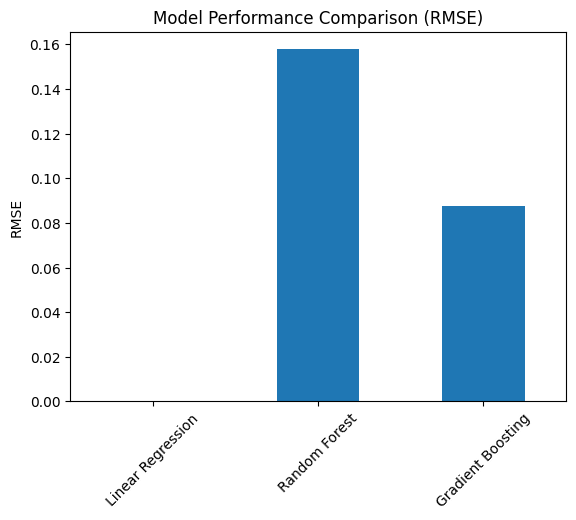

In [ ]:
plt.figure()
results_df["RMSE"].plot(kind="bar")
plt.ylabel("RMSE")
plt.title("Model Performance Comparison (RMSE)")
plt.xticks(rotation=45)
plt.show()


In [ ]:
preds = best_model.predict(X_test)


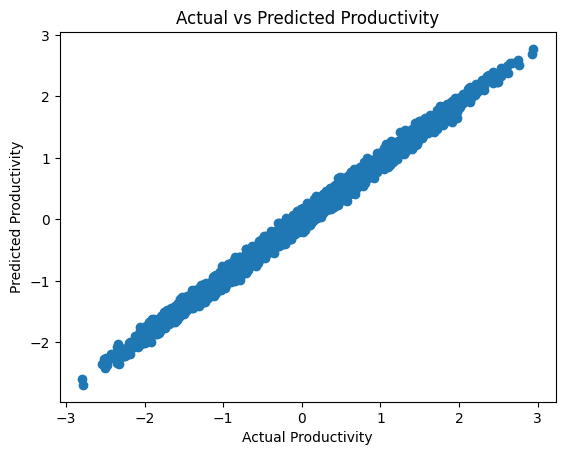

In [ ]:
plt.figure()
plt.scatter(y_test, preds)
plt.xlabel("Actual Productivity")
plt.ylabel("Predicted Productivity")
plt.title("Actual vs Predicted Productivity")
plt.show()


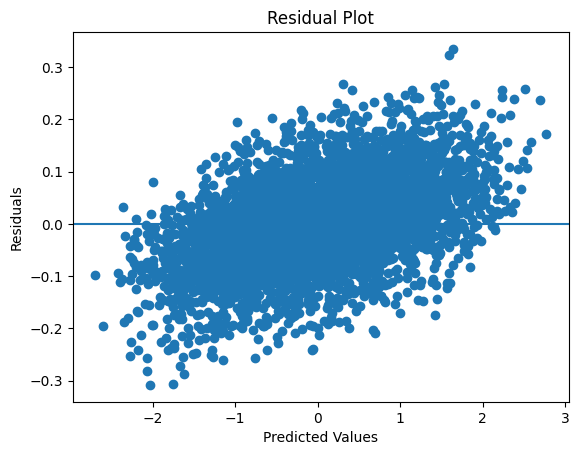

In [ ]:
residuals = y_test - preds

plt.figure()
plt.scatter(preds, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


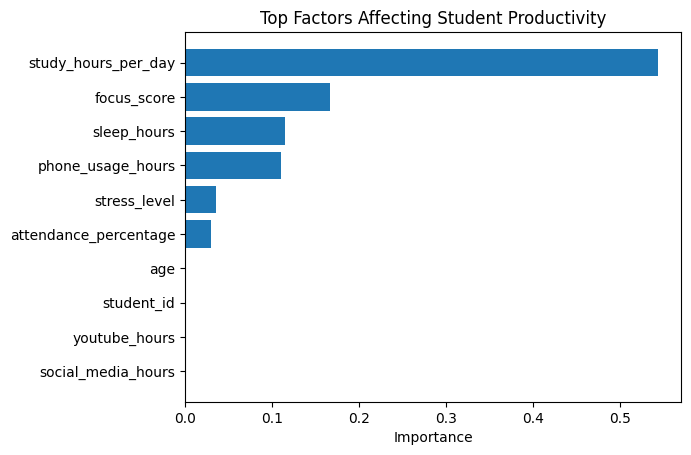

In [ ]:
importance_sorted = importance.sort_values(by="Importance", ascending=False).head(10)

plt.figure()
plt.barh(importance_sorted["Feature"], importance_sorted["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top Factors Affecting Student Productivity")
plt.show()


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("Final Model Performance")
print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)


Final Model Performance
R2: 0.992319460557366
RMSE: 0.08743914914126094
MAE: 0.06916129593023358
